# Undamped oscillations: Find the spring constant.

## Chunky spring
The equilibrium position was around 0.317 $\pm$ 0.001 [m]

In [1]:
#Import useful libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import scipy.optimize as opt
import scienceplots

In [2]:
# Set plots style
plt.style.use(['science', 'notebook', 'no-latex'])

In [3]:
def readpendulum(filename):
    '''
    This function reads the data taken of position and time from a damped pendulum.
    Input: filename (string)
    Output: weigths (array), distance (array)
    Algorithm:
        Read the file using Pandas and convert it to a DataFrame
        Extract the columns using the Titles as indeces
        Convert each row to an array
        Return time, position
    Author: AlejoS
    Date modified: 08/03/2025
    '''
    file = pd.read_csv(filename, sep=',') #we have inspected the file beforehand, it's .csv
    
    distance = np.array(file["Distance (cm)"])
    weights = np.array(file["Weights (g)"])

    return distance, weights

In [4]:
file_chunky = "/home/prostofsound/jnotebooks/Waves & Oscillations/data/Lab1_Waves_chunkyspring.csv"

distance, weights = readpendulum(file_chunky)

new_distance = distance/100.
new_force = weights*9.8/1000.
#print(distance)
#print(weights)

In [5]:
equilibrium_c = 0.317
new_extension_c = new_distance - equilibrium_c

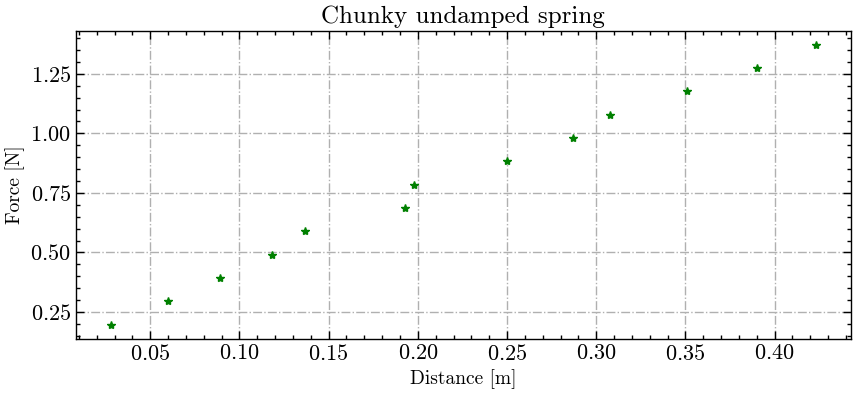

In [6]:
#Plotting
# Open env and stablish the figure size
plt.figure(figsize=(10,4))

plt.plot(new_extension_c, new_force, color = "green", linestyle = " ", marker = "*") #change of units and the vertical force

# Title with latex syntax
plt.title("Chunky undamped spring", fontsize = 18)

# Axes titles
plt.xlabel("Distance [m]", fontsize = 14)
plt.ylabel("Force [N]", fontsize = 14)

# Show/Save
plt.grid(linestyle = '-.') #nice grid style
plt.show()
plt.close()

In [7]:
# Let's calculate these coefficients

# 1. Spearman coefficient
sp = st.spearmanr(distance, weights)

# 2. Pearson coefficient
pe = st.pearsonr(distance, weights)

print("Spearman:\n", sp)

print("Pearson:\n", pe) #the pvalues are the leftovers, the probability of the expected distributions just being by chance. These values are on the 
# outskirts of the distribution

Spearman:
 SignificanceResult(statistic=1.0, pvalue=0.0)
Pearson:
 PearsonRResult(statistic=0.9974749981810402, pvalue=5.462637553481726e-14)


Since we have a clear linear relation. We can just use a polynomial of degree one to do the fitting and find the slope.

In [8]:
def fit_model(x_values, m, b):
    """
    Function to define model to fut experimental data.
    In this case we use a linear polynomial
    Inputs: x_values (data vector), m -> slope, b -> intercept with Y-axis
    Output: y_values (linear finction)
    """
    y_values = m * x_values + b
    
    return y_values

In [9]:
# Call the curve_fit() function
coef, cova = opt.curve_fit(fit_model, new_extension_c, new_force) #model, x-data, y-data. We can also add an initial guess for the parameters and
#the uncertainty in the y-data

#Double check
#print(cova) # Covariance matrix
#print(coef) # The fitting parameters (optimal)
#print(*coef) #print parammeters out of the array
#print(type(cova)) # We got numpy arrays

# Print result:
print('m = %.5f , b = %.5f' % (coef[0], coef[1]))

m = 2.96014 , b = 0.13914


In [10]:
#Evaluate the model on the data
fit_sconstant= fit_model(new_extension_c, *coef)

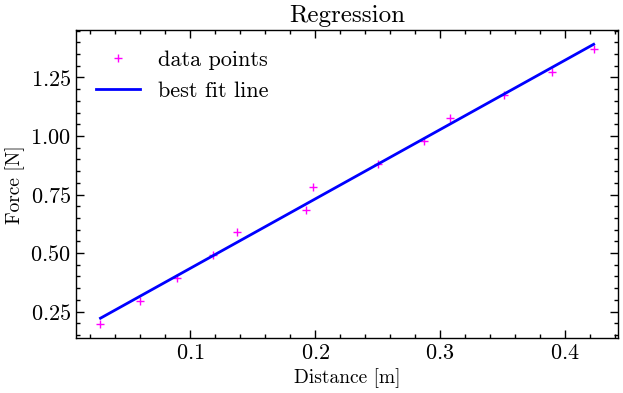

In [11]:
# Replot the data with the fit

# Figure environment
plt.figure(figsize = (7,4))

plt.title("Regression", fontsize = 18)
plt.plot(new_extension_c, new_force, color = "magenta", marker = "+",\
        linestyle = " ", label = "data points")

plt.plot(new_extension_c, fit_sconstant, color = "blue",\
        linestyle = "-", label = "best fit line")

# Customisation
plt.xlabel("Distance [m]", fontsize = 14)
plt.ylabel("Force [N]", fontsize = 14)
plt.legend()

plt.savefig("k_chunky.pdf")
plt.show()

In [12]:
# Compute the errors

err= np.sqrt(np.diag(cova))

print("Error in m is %.5f" % (err[0]))
print("Error in b is %.5f" % (err[1]))
print("\n")
# Print result:
print('The spring constant for the chunky spring is k = (%.5f +/- %.5f)' % (coef[0], err[0]) ,'[N/m]')

Error in m is 0.06355
Error in b is 0.01591


The spring constant for the chunky spring is k = (2.96014 +/- 0.06355) [N/m]


## Slim spring
The equilibrium position was around 0.319 $\pm$ 0.001 [m]

In [13]:
def readpendulum2(filename):
    '''
    This function reads the data taken of position and time from a damped pendulum.
    Input: filename (string)
    Output: weights (array), distance (array)
    Algorithm:
        Read the file using Pandas and convert it to a DataFrame
        Extract the columns using the Titles as indeces
        Convert each row to an array
        Return distance, weight
    Author: AlejoS
    Date modified: 08/03/2025
    '''
    file = pd.read_csv(filename, sep=',') #we have cat the file before and check it is csv
    
    distance = np.array(file["Distance (cm) "])
    weights = np.array(file["Weights (g)"])

    return distance, weights

In [14]:
file_slim = "/home/prostofsound/jnotebooks/Waves & Oscillations/data/Lab1_Waves_slimspring.csv"

distance_s, weights_s = readpendulum2(file_slim)

new_distance_s = distance_s/100.
new_force_s = weights_s*9.8/1000.
#print(distance_s)
#print(weights_s)

In [15]:
equilibrium_s = 0.319
new_extension_s = new_distance_s - equilibrium_s

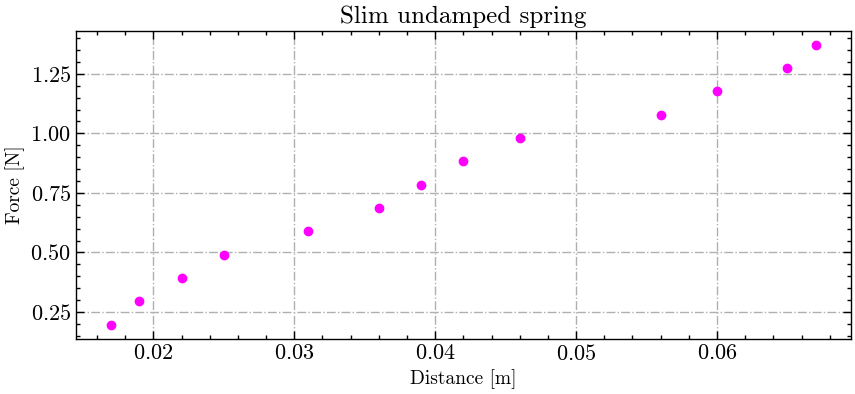

In [16]:
#Plotting
# Open env and stablish the figure size
plt.figure(figsize=(10,4))

plt.plot(new_extension_s, new_force_s, color = "magenta", linestyle = " ", marker = "o") #change of units and the vertical force

# Title with latex syntax
plt.title("Slim undamped spring", fontsize = 18)

# Axes titles
plt.xlabel("Distance [m]", fontsize = 14)
plt.ylabel("Force [N]", fontsize = 14)

# Show/Save
plt.grid(linestyle = '-.') #nice grid style
plt.show()
plt.close()

In [17]:
# Let's calculate these coefficients

# 1. Spearman coefficient
sp = st.spearmanr(distance_s, weights_s)

# 2. Pearson coefficient
pe = st.pearsonr(distance_s, weights_s)

print("Spearman:\n", sp)

print("Pearson:\n", pe) #the pvalues are the leftovers, the probability of the expected distributions just being by chance. These values are on the 
# outskirts of the distribution

Spearman:
 SignificanceResult(statistic=1.0, pvalue=0.0)
Pearson:
 PearsonRResult(statistic=0.9929871150974297, pvalue=1.4916859326807158e-11)


In [18]:
# Call the curve_fit() function
coef2, cova2 = opt.curve_fit(fit_model, new_extension_s, new_force_s) #model, x-data, y-data. We can also add an initial guess for the parameters and
#the uncertainty in the y-data

#Double check
#print(cova) # Covariance matrix
#print(coef) # The fitting parameters (optimal)
#print(*coef) #print parammeters out of the array
#print(type(cova)) # We got numpy arrays

# Print result:
print('m = %.5f , b = %.5f' % (coef2[0], coef2[1]))

m = 21.68522 , b = -0.09175


In [19]:
#Evaluate the model on the data
fit_sconstant2= fit_model(new_extension_s, *coef2)

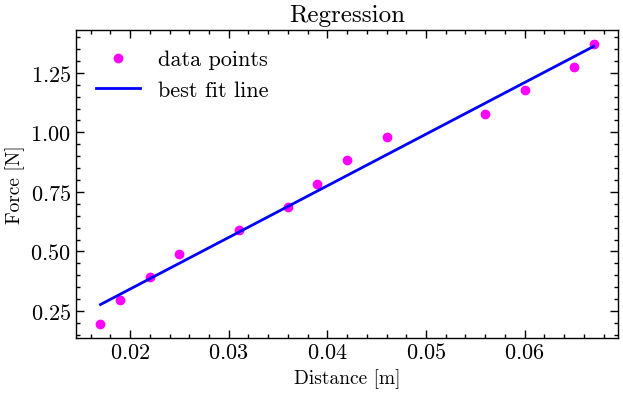

In [20]:
# Replot the data with the fit

# Figure environment
plt.figure(figsize = (7,4))

plt.title("Regression", fontsize = 18)
plt.plot(new_extension_s, new_force_s, color = "magenta", marker = "o",\
        linestyle = " ", label = "data points")

plt.plot(new_extension_s, fit_sconstant2, color = "blue",\
        linestyle = "-", label = "best fit line")

# Customisation
plt.xlabel("Distance [m]", fontsize = 14)
plt.ylabel("Force [N]", fontsize = 14)
plt.legend()

plt.savefig("k_slim.pdf")
plt.show()

In [21]:
# Compute the errors

err2= np.sqrt(np.diag(cova2))

print("Error in m is %.5f" % (err2[0]))
print("Error in b is %.5f" % (err2[1]))
print("\n")
# Print result:
print('The spring constant for the slim spring is k = (%.5f +/- %.5f)' % (coef2[0], err2[0]) ,'[N/m]')

Error in m is 0.77844
Error in b is 0.03405


The spring constant for the slim spring is k = (21.68522 +/- 0.77844) [N/m]


# Damped oscillations: Find the behavior of the system.

## Chunky spring

In [22]:
def readpendulum3(filename):
    '''
    This function reads the data taken of position and time from a damped pendulum.
    Input: filename (string)
    Output: time (array), distance (array)
    Algorithm:
        Read the file using Pandas and convert it to a DataFrame
        Extract the columns using the Titles as indeces
        Convert each row to an array
        Return time, position
    Author: AlejoS
    Date modified: 08/05/2025
    '''
    file = pd.read_csv(filename, sep=';') #we have cat the file before and check it is csv
    
    time = np.array(file["Time [s]"])
    distance = np.array(file["Displacement [cm]"])

    return time, distance

In [23]:
file_chunky = "/home/prostofsound/jnotebooks/Waves & Oscillations/data/damped_smallest_k.csv"

time1, distance1 = readpendulum3(file_chunky)

distance1 = distance1/100
#print(distance1)
#print(time1)

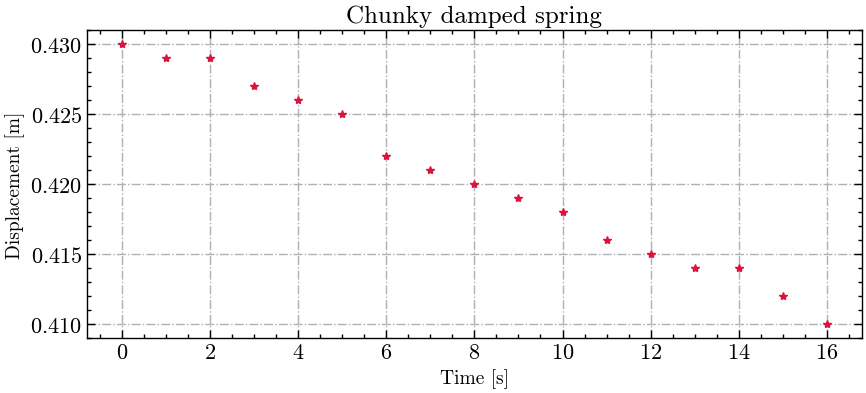

In [24]:
#Plotting
# Open env and stablish the figure size
plt.figure(figsize=(10,4))

plt.plot(time1, distance1, color = "crimson", linestyle = " ", marker = "*") #change of units and the vertical force

# Title with latex syntax
plt.title("Chunky damped spring", fontsize = 18)

# Axes titles
plt.xlabel("Time [s]", fontsize = 14)
plt.ylabel("Displacement [m]", fontsize = 14)

# Show/Save
plt.grid(linestyle = '-.') #nice grid style
plt.show()
plt.close()

We observe a smooth decay, no oscillations are present. We present a model tailored to this behavior.

In [25]:
def model_dp(t, A, gamma, C):
    """
    This function returns the position of the damped pendulum, given the parammeters: beta(b/2m, gama is the damping coeffcient),
    C (asymptotic offset), A (amplitude), t (time, we have to discretize the time, i.e, create an array)

    t is not a parammeter
    """
    y = A*np.exp(-gamma*t) + C
    
    return y

In [26]:
# Carry out the fitting
coef_3, cov_3 = opt.curve_fit(model_dp, time1, distance1, p0=[0.02, 0.1, 0.41])

# print(coef_3)
# print(cov_3)

#Evaluate the best fit parammeters into our model.
fit_dpendulum = model_dp(time1, *coef_3)

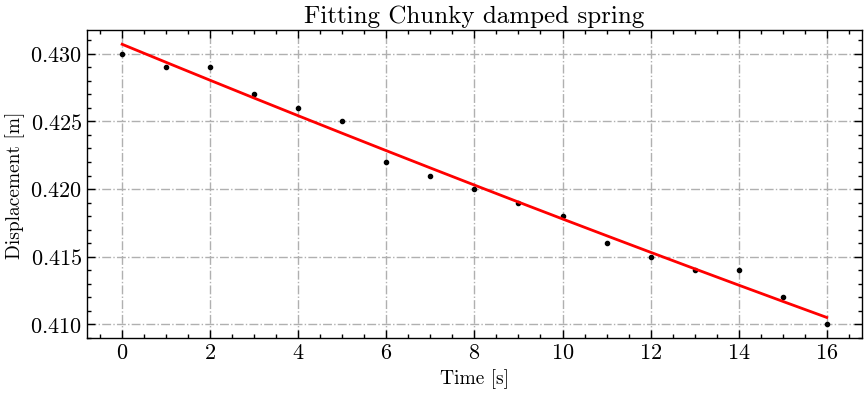

In [27]:
#Plotting
# Open env and stablish the figure size
plt.figure(figsize=(10,4))

plt.plot(time1, distance1, color = "k", linestyle = " ", marker = ".") #data points
plt.plot(time1, fit_dpendulum, color = "red", linestyle = "-") #best-fit model

# Title with latex syntax
plt.title("Fitting Chunky damped spring", fontsize = 18)

# Axes titles
plt.xlabel("Time [s]", fontsize = 14)
plt.ylabel("Displacement [m]", fontsize = 14)

# Show/Save
plt.grid(linestyle = '-.') #nice grid style
plt.savefig("damped_chunky.pdf")
plt.show()

### Reporting:

In [28]:
# Function
def reporting(coef, cova, coef_name):
    """
    """
    # Uncertainties
    uncertainties = np.sqrt(np.diag(cova))

    # Run this loop
    for i in range(len(coef)):
        print(f'{coef_name[i]:.6} = {coef[i]:.6} +/- {uncertainties[i]:.6}')

    return uncertainties

In [29]:
# Define the names
coef_names = ['A', 'gamma', 'C']

# Call the function
uncertainties_array = reporting(coef_3, cov_3, coef_names)

A = 0.173781 +/- 0.246292
gamma = 0.00772316 +/- 0.0116523
C = 0.256926 +/- 0.246583


In [30]:
#gamma = b/2m
m = 20/1000
gamma = coef_3[1]
b = gamma*2*m

#To get the uncertainty of b, we also consider the uncertainty of beta
uncertainties_3 = np.sqrt(np.diag(cov_3))
b_uncertainty = uncertainties_3[1]*2

print(f'b = {b:.6g} +/- {b_uncertainty:.6g} [kg/s]')

b = 0.000308926 +/- 0.0233045 [kg/s]


We have $k$ from the first experiment. Then, to determine the $\omega$ we use:
$$
\omega = \sqrt{\frac{k}{m} - \frac{b²}{4 m²}}
$$

In [31]:
k_chunky = 2.96014 #approx.
b_chunky = 0.000308926 #approx.

#Compute omega
omega = np.sqrt((k_chunky/m) - (b_chunky**2/(4*m**2)))
print(f"ω = {omega:.6f} [rad/s]")

ω = 12.165810 [rad/s]


## Slim spring

In [32]:
file_slim = "/home/prostofsound/jnotebooks/Waves & Oscillations/data/damped_largest_k.csv"

time1, distance1 = readpendulum3(file_slim)

distance1 = distance1/100.
#print(distance1)
#print(time1)

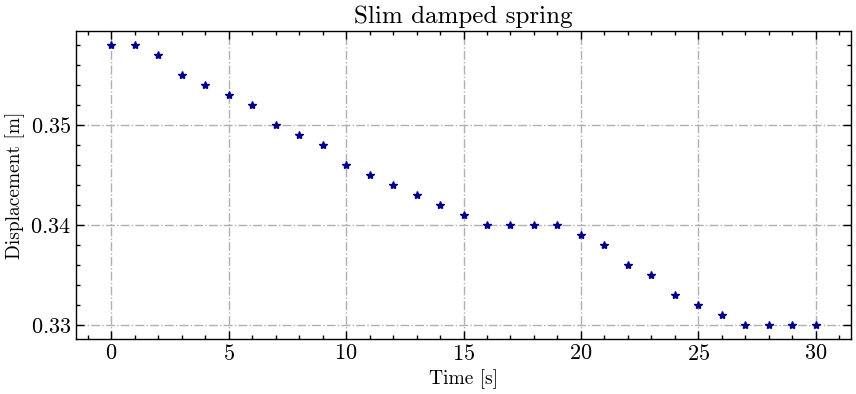

In [33]:
#Plotting
# Open env and stablish the figure size
plt.figure(figsize=(10,4))

plt.plot(time1, distance1, color = "darkblue", linestyle = " ", marker = "*") #change of units and the vertical force

# Title with latex syntax
plt.title("Slim damped spring", fontsize = 18)

# Axes titles
plt.xlabel("Time [s]", fontsize = 14)
plt.ylabel("Displacement [m]", fontsize = 14)

# Show/Save
plt.grid(linestyle = '-.') #nice grid style
plt.show()
plt.close()

In [34]:
# Carry out the fitting
coef_4, cov_4 = opt.curve_fit(model_dp, time1, distance1)

# print(coef_4)
# print(cov_4)

#Evaluate the best fit parammeters into our model.
fit_dpendulum = model_dp(time1, *coef_4)

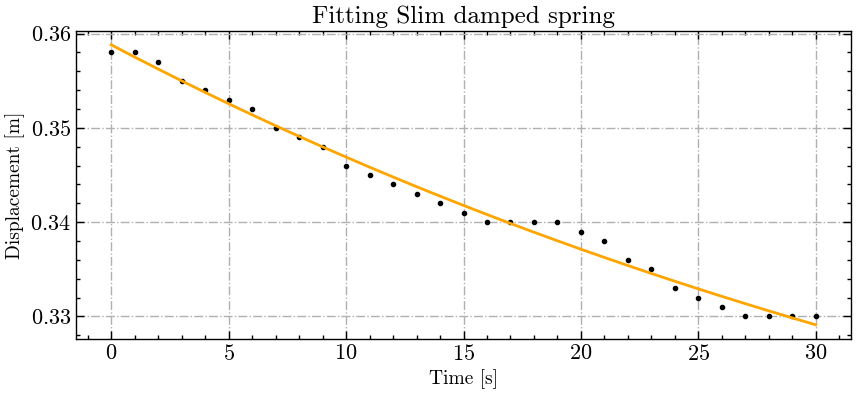

In [35]:
#Plotting
# Open env and stablish the figure size
plt.figure(figsize=(10,4))

plt.plot(time1, distance1, color = "k", linestyle = " ", marker = ".") #data points
plt.plot(time1, fit_dpendulum, color = "orange", linestyle = "-") #best-fit model

# Title with latex syntax
plt.title("Fitting Slim damped spring", fontsize = 18)

# Axes titles
plt.xlabel("Time [s]", fontsize = 14)
plt.ylabel("Displacement [m]", fontsize = 14)

# Show/Save
plt.grid(linestyle = '-.') #nice grid style
plt.savefig("damped_slim.pdf")
plt.show()

### Reporting:

In [36]:
# Define the names
coef_names = ['A', 'gamma', 'C']

# Call the function
uncertainties_array = reporting(coef_4, cov_4, coef_names)

A = 0.0663956 +/- 0.0118247
gamma = 0.0197712 +/- 0.00480744
C = 0.292417 +/- 0.0121518


In [37]:
#gamma = b/2m
m = 60/1000
gamma = coef_4[1]
b = gamma*2*m

#To get the uncertainty of b, we also consider the uncertainty of beta
uncertainties_4 = np.sqrt(np.diag(cov_4))
b_uncertainty = uncertainties_4[1]*2

print(f'b = {b:.6g} +/- {b_uncertainty:.6g} [kg/s]')

b = 0.00237254 +/- 0.00961489 [kg/s]


In [38]:
k_slim = 21.68522 #approx.
b_slim = 0.00237254 #approx.

#Compute omega
omega = np.sqrt((k_slim/m) - (b_slim**2/(4*m**2)))
print(f"ω = {omega:.6f} [rad/s]")

ω = 19.011048 [rad/s]


## Behavior in water (Chunky spring)

In [39]:
file_water = "/home/prostofsound/jnotebooks/Waves & Oscillations/data/damped_water.csv"

time1, distance1 = readpendulum3(file_water)

distance1 = distance1/100.
#print(distance1)
#print(time1)

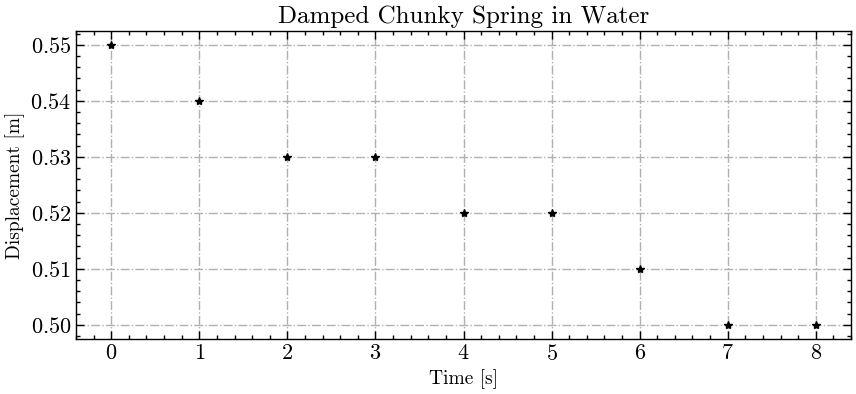

In [40]:
#Plotting
# Open env and stablish the figure size
plt.figure(figsize=(10,4))

plt.plot(time1, distance1, color = "black", linestyle = " ", marker = "*") #change of units and the vertical force

# Title with latex syntax
plt.title("Damped Chunky Spring in Water", fontsize = 18)

# Axes titles
plt.xlabel("Time [s]", fontsize = 14)
plt.ylabel("Displacement [m]", fontsize = 14)

# Show/Save
plt.grid(linestyle = '-.') #nice grid style
plt.show()
plt.close()

In [41]:
# Carry out the fitting
coef_5, cov_5 = opt.curve_fit(model_dp, time1, distance1)

# print(coef_4)
# print(cov_4)

#Evaluate the best fit parammeters into our model.
fit_dpendulum = model_dp(time1, *coef_5)

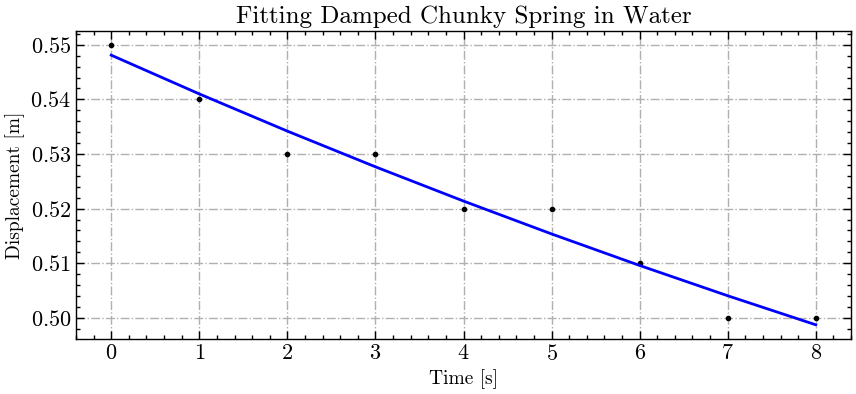

In [42]:
#Plotting
# Open env and stablish the figure size
plt.figure(figsize=(10,4))

plt.plot(time1, distance1, color = "k", linestyle = " ", marker = ".") #data points
plt.plot(time1, fit_dpendulum, color = "blue", linestyle = "-") #best-fit model

# Title with latex syntax
plt.title("Fitting Damped Chunky Spring in Water", fontsize = 18)

# Axes titles
plt.xlabel("Time [s]", fontsize = 14)
plt.ylabel("Displacement [m]", fontsize = 14)

# Show/Save
plt.grid(linestyle = '-.') #nice grid style
plt.savefig("damped_water.pdf")
plt.show()

### Reporting:

In [43]:
# Define the names
coef_names = ['A', 'gamma', 'C']

# Call the function
uncertainties_array = reporting(coef_5, cov_5, coef_names)

A = 0.175946 +/- 0.227257
gamma = 0.0411851 +/- 0.0629321
C = 0.372155 +/- 0.228975


In [44]:
#gamma = b/2m
m = 60/1000
gamma = coef_5[1]
b = gamma*2*m

#To get the uncertainty of b, we also consider the uncertainty of beta
uncertainties_5 = np.sqrt(np.diag(cov_5))
b_uncertainty = uncertainties_5[1]*2

print(f'b = {b:.6g} +/- {b_uncertainty:.6g} [kg/s]')

b = 0.00494221 +/- 0.125864 [kg/s]


In [45]:
k_chunky = 2.96014 #approx.
b_chunky = 0.00494221 #approx.

#Compute omega
omega = np.sqrt((k_chunky/m) - (b_chunky**2/(4*m**2)))
print(f"ω = {omega:.6f} [rad/s]")

ω = 7.023815 [rad/s]
